# Introducción

## Importar librerías

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Valores nominales

In [2]:
# Datos del POI
VnPOI = 115 #kV

# Datos del inversor
Sn = 120 # MVA
Vterm = 0.6 #kV
IBaseIBR = Sn/(np.sqrt(3)*Vterm) # kA

## Definición de funciones

In [3]:
# Función para calcular las columnas adicionales en el DataFrame de PSS/E
def read_csv_pss_file(path , test_dict, test_key):
    test_name = test_dict.get(test_key, 'Error')[1]
    directory = path + "\\" + test_name
    if directory is None or not os.path.isfile(directory):
        app.PrintWarn(f"Prueba {test_key:02d} de PSS/E no disponible.")
        return 'Error'
    else:
        pssframe = pd.read_csv(directory, skiprows=1)
        Vt_angle = pssframe[' IBRT_ANGLE']
        
        pssframe['IBR_P (MW)']    = pssframe[' IBR_P']*100
        pssframe['IBR_Q (MVAR)']  = pssframe[' IBR_Q']*100
        pssframe['IBR_S (MVA)']   = np.sqrt(pssframe['IBR_P (MW)']**2 + pssframe['IBR_Q (MVAR)']**2)

        pssframe['IBR_V (kV)']    = pssframe[' IBRT_V']*Vterm
        pssframe['IBR_VINT (kV)'] = pssframe[' IBR_VT']*Vterm
        
        pssframe['IBR_ID (kA)']   = pssframe['IBR_P (MW)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']
        pssframe['IBR_IQ (kA)']   = pssframe['IBR_Q (MVAR)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']
        pssframe['IBR_pf (pu)']   = abs(pssframe['IBR_P (MW)']/pssframe['IBR_S (MVA)'])

        pssframe['PLL_DELTA (Degree)'] = pssframe[' IBR_DELTA_PLL']*180/np.pi
        pssframe['VQ_PLL (kV)']   = pssframe['IBR_V (kV)']*np.sin((Vt_angle-pssframe['PLL_DELTA (Degree)'])*np.pi/180)

        pssframe['POI_V (kV)']    = pssframe[' POI_V']*VnPOI
        pssframe['POI_S (MVA)']   = np.sqrt(pssframe[' POI_P']**2 + pssframe[' POI_Q']**2)
        pssframe['POI_pf (pu)']   = abs(pssframe[' POI_P']/pssframe['POI_S (MVA)'])
        pssframe['POI_FRQ (Hz)']  = pssframe[' POI_FREQ']*60+60
        return pssframe

In [4]:
# Función para procesar los encabezados del archivo de resultados de DIgSILENT
def read_csv_dsl_file(path , test_dict, test_key):
    test_name = test_dict.get(test_key, 'Error')[0]
    directory = path + "\\" + test_name
    if directory is None or not os.path.isfile(directory):
        app.PrintWarn(f"Prueba {test_key:02d} de DIgSILENT no disponible.")
        return 'Error'
    else:
        dslframe = pd.read_csv(directory, header=None, low_memory=False)
        tmprow = dslframe.iloc[0].astype(str) + ' ' + dslframe.iloc[1].astype(str)
        tmp_df = dslframe.drop([0,1], axis=0)
        dslframe = pd.concat([tmprow.to_frame().T, tmp_df], ignore_index=True)
        dslframe.iloc[0,0] = 'Time in S'
        dslframe.columns = dslframe.iloc[0]
        dslframe.drop([0], axis=0, inplace=True)
        dslframe = dslframe.apply(pd.to_numeric)

        dslframe['POI m:cosphi:bus1'] = dslframe['POI m:cosphi:bus1'].abs()

        return dslframe

## DIgSILENT

Toda esta sección se puede desactivar si no se cuenta con DIgSILENT o si ya se cuenta con los archivos de resultados

In [5]:
os.environ["PATH"] = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP1" + os.environ["PATH"]  # Importamos estas librerías y archivos para enlazar nuestro intérprete de python (En mi caso, Spyder) con DIgSILENT
sys.path.append("C:\\Program Files\\DIgSILENT\\PowerFactory 2025 SP1\\Python\\3.11")
import powerfactory
app = powerfactory.GetApplicationExt() # Importamos las librerías de DIgSILENT y otras librerías que se usan en el código
app.Show()                             # mostramos DIgSILENT en pantalla para ver qué está haciendo
user = app.GetCurrentUser()            # Obtenemos el usuario activo

Activar proyecto

In [6]:
oProject = user.GetContents('DYN DIgSILENT x PSSE.IntPrj')[0]  # Seleccionamos el primer proyecto dentro del folder
oProject.Activate()                                            # Activamos el proyecto

0

### REPC_D

In [7]:
REPC_D_modes = [
    # 'REPC_D Modo 01', # Reactiva
    'REPC_D Modo 02', # Reactiva con PI de P
    # 'REPC_D Modo 03', # Voltaje
    # 'REPC_D Modo 04', # Voltaje con PI de P
    # 'REPC_D Modo 05', # Factor de potencia
    # 'REPC_D Modo 06'  # Factor de potencia con PI de P
]

In [8]:
# Main switch para variación del modelo
REEC_E_modes = [
    'REEC_E Modo 01',
    # 'REEC_E Modo 03',
    # 'REEC_E Modo 05',
    # 'REEC_E Modo 06'
]


In [9]:
oFoldVarts = app.GetProjectFolder('scheme')     # Seleccionamos el folder de variaciones
oFoldStudyGral = app.GetProjectFolder('study')      # Seleccionamos el folder de casos de estudio
oFoldREECE = oFoldVarts.GetContents('REEC_E')[0]
oFoldREPCD = oFoldVarts.GetContents('REPC_D')[0]
dsl_folder_main = r"C:\Users\diego.montesanos\OneDrive - Funken Ingenieros S.A. de C.V\Documentos\FKTrabajo\2026 22 Dinámica PSSE Vs DIgSILENT\REPC_D"

app.EchoOff()  # Congelamos la interfaz del usuario
app.ClearOutputWindow()  # Borramos el "Output window"

dsl_names = {
    0 : ['00 - Inicio Plano.csv', "ARRANQUE_PLANO\ibr_plano.csv"],
    # 1 : ['01 - Falla parcial.csv', "FALLAS\FALLA_PARCIAL\ibr_falla_parcial.csv"],
    # 2 : ['02 - Falla total.csv', "FALLAS\FALLA_TOTAL\ibr_falla_total.csv"],
    # 3 : ['03 - Perturbación de fase.csv', "PERTURBACIONES\PERT_FASE\ibr_pert_fase.csv"],
    4 : ['04 - Perturbación de frecuencia.csv', "PERTURBACIONES\PERT_FRECUENCIA - PASO\ibr_pert_frq.csv"],
    5 : ['05 - Perturbación de voltaje.csv', "PERTURBACIONES\PERT_VOLTAJE\ibr_pert_voltaje.csv"],
    # 6 : ['06 - Escalón Paux.csv', "ESCALONES\ESC_PAUX_REECE\ibr_escalones_paux.csv"],
    # 7 : ['07 - Escalón Pref.csv', "ESCALONES\ESC_PREF_REECE\ibr_escalones_pref.csv"],
    # 8 : ['08 - Escalón Qref.csv', "ESCALONES\ESC_QREF_REECE\ibr_escalones_qref.csv"],
    # 9 : ['09 - REPCD Escalón Qref.csv', "ESCALONES\ESC_QREF_PLNTB\ibr_escalones_qref.csv"],
    # 10: ['10 - REPCD Escalón Vref.csv', "ESCALONES\ESC_VREF_PLNTB\ibr_escalones_vref.csv"],
    # 11: ['11 - REPCD Escalón PFref.csv', "ESCALONES\ESC_PFREF_PLNTB\ibr_escalones_pfref.csv"],
    # 12: ['12 - REPCD Escalón Paux.csv', "ESCALONES\ESC_PREF_PLNTB\ibr_escalones_pref.csv"],
    # 13: ['13 - REPCD Escalón Fref.csv', "ESCALONES\ESC_FREF_PLNTB\ibr_escalones_fref.csv"]
}

app.PrintPlain('Realizando simulaciones dinámicas...\n')
print("Realizando simulaciones dinámicas...\n")
for REPC_D_mode in REPC_D_modes:
    oVarsREPCD = oFoldREPCD.GetContents(REPC_D_mode)[0]  # Obtenemos la variacion del REPC_D que queremos activar para cada caso de estudio
    oStgeREPCD = oVarsREPCD.GetContents('*.IntSstage')[0]
    for REEC_E_mode in REEC_E_modes:
        sFold = REPC_D_mode + " - REEC_E " + REEC_E_mode[-2:]

        oFoldStudy = oFoldStudyGral.GetContents(sFold)[0]  # Seleccionar el folder de estudio indicado en "folder"
        app.PrintPlain(f"Procesando el folder: {oFoldStudy}")
        print(f"Procesando el folder: {oFoldStudy.loc_name}")
        oVarsREECE = oFoldREECE.GetContents(REEC_E_mode)[0]  # Obtenemos la variacion que queremos activar para cada caso de estudio
        
        dsl_folder = dsl_folder_main + "\\" + sFold
        os.makedirs(dsl_folder, exist_ok=True)

        # Todos los casos de estudio en el folder especificado
        sStudyCase = oFoldStudy.GetContents('*.IntCase')
        sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

        # for oStudyCase in sStudyCase:
        #     nCase = int(oStudyCase.loc_name[0:2])
        #     if nCase in dsl_names.keys():
        #         app.PrintPlain(f"   Procesando el caso de estudio: {oStudyCase}...")
                
        #         oStudyCase.Activate()

        #         sActiveVar = app.GetActiveNetworkVariations()   # Obtenemos las variaciones activas en el caso de estudio
        #         [oActiveVar.Deactivate() for oActiveVar in sActiveVar]
        #         oVarsREECE.Activate()
        #         oVarsREPCD.Activate()
        #         oStgeREPCD.Activate(1)
                
        #         oInit = oStudyCase.GetContents('*.ComInc')[0]
        #         oRun  = oStudyCase.GetContents('*.ComSim')[0]
        #         oInit.Execute()
        #         oRun.Execute()

        #         oElmRes = app.GetFromStudyCase('ElmRes')
        #         oElmExp = app.GetFromStudyCase('ComRes')

        #         oElmExp.iopt_exp = 6
        #         oElmExp.f_name = dsl_folder + "\\" + dsl_names[nCase][0]
        #         oElmExp.pResult = oElmRes
        #         oElmExp.Execute()

        dsl_00 = read_csv_dsl_file(dsl_folder, dsl_names, 0)
        dsl_01 = read_csv_dsl_file(dsl_folder, dsl_names, 1)
        dsl_02 = read_csv_dsl_file(dsl_folder, dsl_names, 2)
        dsl_03 = read_csv_dsl_file(dsl_folder, dsl_names, 3)
        dsl_04 = read_csv_dsl_file(dsl_folder, dsl_names, 4)
        dsl_05 = read_csv_dsl_file(dsl_folder, dsl_names, 5)
        dsl_06 = read_csv_dsl_file(dsl_folder, dsl_names, 6)
        dsl_07 = read_csv_dsl_file(dsl_folder, dsl_names, 7)
        dsl_08 = read_csv_dsl_file(dsl_folder, dsl_names, 8)
        dsl_09 = read_csv_dsl_file(dsl_folder, dsl_names, 9)
        dsl_10 = read_csv_dsl_file(dsl_folder, dsl_names, 10)
        dsl_11 = read_csv_dsl_file(dsl_folder, dsl_names, 11)
        dsl_12 = read_csv_dsl_file(dsl_folder, dsl_names, 12)
        dsl_13 = read_csv_dsl_file(dsl_folder, dsl_names, 13)
app.EchoOn()  # Descongelamos la interfaz del usuario

Realizando simulaciones dinámicas...

Procesando el folder: REPC_D Modo 02 - REEC_E 01


## PSS/E

In [10]:
dir_temp = r'X:\2026 Modelos IBR PSSE - DIgSILENT\REGCC + REECE + PLNTB - PSSE'
dir_repc = "\\" + REPC_D_modes[0][7:].upper()
dir_reec = " - " + 'REECE ' + REEC_E_modes[0][7:].upper() + "\\"
pss_path = dir_temp + dir_repc + dir_reec
pss_path

pss_00 = read_csv_pss_file(pss_path, dsl_names, 0)
pss_01 = read_csv_pss_file(pss_path, dsl_names, 1)
pss_02 = read_csv_pss_file(pss_path, dsl_names, 2)
pss_03 = read_csv_pss_file(pss_path, dsl_names, 3)
pss_04 = read_csv_pss_file(pss_path, dsl_names, 4)
pss_05 = read_csv_pss_file(pss_path, dsl_names, 5)
pss_06 = read_csv_pss_file(pss_path, dsl_names, 6)
pss_07 = read_csv_pss_file(pss_path, dsl_names, 7)
pss_08 = read_csv_pss_file(pss_path, dsl_names, 8)
pss_09 = read_csv_pss_file(pss_path, dsl_names, 9)
pss_10 = read_csv_pss_file(pss_path, dsl_names, 10)
pss_11 = read_csv_pss_file(pss_path, dsl_names, 11)
pss_12 = read_csv_pss_file(pss_path, dsl_names, 12)
pss_13 = read_csv_pss_file(pss_path, dsl_names, 13)

# Root Mean Squared Error

In [ ]:
# Half-up value round
# Esto se hace porque para python round(0.035) = round(0.045) = 0.4 y esto claramente es incorrecto según lo que se nos enseña en la escuela
def HUP_round(series, decimals):
    factor = 10**decimals
    return np.floor(series * factor +0.5)/factor

In [ ]:
juan = dsl_00[['Time in S', 'POI Bus m:Ul in kV']].rename(columns={'Time in S': 'Time(s)'})
juan.loc[:,'Time(s)'] = HUP_round(juan['Time(s)'],3)
juan

In [ ]:
rober = pss_00[['Time(s)',' POI_V']]
rober.loc[:,' POI_V'] = rober[' POI_V']*115
rober.loc[:,'Time(s)'] = HUP_round(rober['Time(s)'], 3)
dupl_filter = rober.loc[:,'Time(s)'].duplicated(keep=False)
rober[dupl_filter]

In [ ]:
pss_00[['Time(s)',' POI_V']][dupl_filter]

In [ ]:
jose = pd.merge(juan, rober, how='inner', on='Time(s)')
jose

In [ ]:
jose.shape[0]

In [ ]:
jose.columns

In [ ]:
np.sqrt(sum((jose['POI Bus m:Ul in kV'] - jose[' POI_V'])**2/jose.shape[0]))

# Root Mean Squared Error ejemplo 2

In [ ]:
def RMSE(series1, series2):
    series1.columns = ['Time', 'Value1']
    series2.columns = ['Time', 'Value2']
    series1.loc[:,'Time'] = HUP_round(series1['Time'], 3)
    series2.loc[:,'Time'] = HUP_round(series2['Time'], 3)
    result = pd.merge(series1, series2, how='inner', on='Time')
    result['sqr. error'] = (result['Value1'] - result['Value2'])**2
    #return result
    return np.sqrt(sum(result['sqr. error']/series1.shape[0]))

### RMSE para corriente en el eje directo del IBR

In [ ]:
# Corriente Eje directo del IBR
dsl_00['IBR m:I1P:bus1 in pu'] = dsl_00['IBR m:I1P:bus1 in kA']/IBaseIBR
pss_00['IBR_ID (pu)'] = pss_00['IBR_ID (kA)']/IBaseIBR

minx = 0
maxx = 20
fig, axs = plt.subplots(figsize=(10,4))
axs.plot(pss_00['Time(s)'], pss_00['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
axs.plot(dsl_00['Time in S'], dsl_00['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
axs.set_ylim(0, IBaseIBR)
axs.set_xlim(minx, maxx)
axs.set_title('Inicio plano')
axs.grid(True)
axs.legend()
plt.show()

In [ ]:
error = RMSE(dsl_00[['Time in S', 'IBR m:I1P:bus1 in pu']], pss_00[['Time(s)', 'IBR_ID (pu)']])
print(f"Error: {error:.8f} pu")
error = RMSE(dsl_00[['Time in S', 'IBR m:I1P:bus1 in kA']], pss_00[['Time(s)', 'IBR_ID (kA)']])
print(f"Error: {error:.8f} kA")
print(f"Error: {error/IBaseIBR:.8f} pu")

In [ ]:
# Corriente Eje directo del IBR
dsl_04['IBR m:I1P:bus1 in pu'] = dsl_04['IBR m:I1P:bus1 in kA']/IBaseIBR
pss_04['IBR_ID (pu)'] = pss_04['IBR_ID (kA)']/IBaseIBR

minx = 0
maxx = 20
fig, axs = plt.subplots(figsize=(10,4))
axs.plot(pss_04['Time(s)'], pss_04['IBR_ID (pu)'], label='PSS/E', linestyle=':', linewidth=2)
axs.plot(dsl_04['Time in S'], dsl_04['IBR m:I1P:bus1 in pu'], label='DIgSILENT') #!!!! Calcular a parte
axs.set_ylim(0, 1)
axs.set_xlim(minx, maxx)
axs.set_title('Perturbación de frecuencia')
axs.grid(True)
axs.legend()
plt.show()

In [ ]:
error = RMSE(dsl_04[['Time in S', 'IBR m:I1P:bus1 in pu']], pss_04[['Time(s)', 'IBR_ID (pu)']])
print(f"Error: {error:.8f} pu")
error = RMSE(dsl_04[['Time in S', 'IBR m:I1P:bus1 in kA']], pss_04[['Time(s)', 'IBR_ID (kA)']])
print(f"Error: {error:.8f} kA")
print(f"Error: {error/IBaseIBR:.8f} pu")

In [ ]:
# Corriente Eje directo del IBR
dsl_05['IBR m:I1P:bus1 in pu'] = dsl_05['IBR m:I1P:bus1 in kA']/IBaseIBR
pss_05['IBR_ID (pu)'] = pss_05['IBR_ID (kA)']/IBaseIBR

minx = 4.997
maxx = 5.01
fig, axs = plt.subplots(figsize=(10,4))
axs.plot(pss_05['Time(s)'], pss_05['IBR_ID (pu)'], label='PSS/E', linestyle=':', linewidth=2)
axs.plot(dsl_05['Time in S'], dsl_05['IBR m:I1P:bus1 in pu'], label='DIgSILENT') #!!!! Calcular a parte
axs.set_ylim(0.72, 0.77)
axs.set_xlim(minx, maxx)
axs.set_title('Perturbación de frecuencia')
axs.grid(True)
axs.legend()
plt.show()

In [ ]:
error = RMSE(dsl_05[['Time in S', 'IBR m:I1P:bus1 in pu']], pss_05[['Time(s)', 'IBR_ID (pu)']])
print(f"Error: {error:.8f} pu")
error = RMSE(dsl_05[['Time in S', 'IBR m:I1P:bus1 in kA']], pss_05[['Time(s)', 'IBR_ID (kA)']])
print(f"Error: {error:.8f} kA")
print(f"Error: {error/IBaseIBR:.8f} pu")

# Derivate series

dy/dt = ys = y(t)-y(t-h) / h

h = t-t0

In [ ]:
def derivative(series):
    if series.shape[1] <= 2:
        orgCol = series.columns
        series.columns = ['Time', 'Value']
        series.loc[:,'Time'] = HUP_round(series['Time'], 3)
        series = series.drop_duplicates(subset=['Time'])
        series = series.reset_index(drop=True)
        
        title = 'd/dt ' + '(' + orgCol[1] + ')'

        # Diferenciación finita por método en atraso, implementado directamente por mí
        # t0 = series.loc[1, 'Time']
        # y0 = series.loc[1, 'Value']
        # series[title] = 0.0
        # for index, row in series.loc[2:, ['Time', 'Value']].iterrows():
        #     t = row['Time']
        #     y = row['Value']
        #     h = t - t0
        #     ys = (y - y0)/h
        #     series.loc[index, title] = ys

        #     t0 = t
        #     y0 = y

        # Diferenciación finita por método central, usando la librería numpy (Que no solo es más simple de 
        # implementar, sino que también es más rápida su ejecución)
        series[title] = np.gradient(series['Value'], 0.001)
        
        series.columns = [orgCol[0], orgCol[1], title]
        return series
    else:
        raise UserWarning('Se debe ingresar un Dataframe con dos columnas (Tiempo, valor)')

#  Derivada y error

In [ ]:
dsl_der05 = derivative(dsl_05[['Time in S', 'IBR m:I1P:bus1 in pu']])
pss_der05 = derivative(pss_05[['Time(s)', 'IBR_ID (pu)']])

In [ ]:
error05 = RMSE(dsl_der05[['Time in S', 'd/dt (IBR m:I1P:bus1 in pu)']], pss_der05[['Time(s)', 'd/dt (IBR_ID (pu))']])
print(f"Error: {error05:.8f} pu")

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(10,8))

minx = 4.9
maxx = 7

axs[0].plot(pss_05['Time(s)'], pss_05['IBR_ID (pu)'], label='PSS/E', linestyle=':', linewidth=3,)
axs[0].plot(dsl_05['Time in S'], dsl_05['IBR m:I1P:bus1 in pu'], label='DIgSILENT') #!!!! Calcular a parte
# axs[0].set_ylim(0.72, 0.77)
axs[0].set_xlim(minx, maxx)
axs[0].set_title('Valor real')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(pss_der05['Time(s)'], pss_der05['d/dt (IBR_ID (pu))'], linestyle=':', linewidth=3, label='PSS/E')
axs[1].plot(dsl_der05['Time in S'], dsl_der05['d/dt (IBR m:I1P:bus1 in pu)'], label='DIgSILENT')
axs[1].set_xlim(minx, maxx)
axs[1].legend()
axs[1].set_title('Derivada del valor')
axs[1].grid(True)

plt.show()

# Ejemplo 2

In [ ]:
dsl_der04 = derivative(dsl_04[['Time in S', 'IBR m:I1P:bus1 in pu']])
pss_der04 = derivative(pss_04[['Time(s)', 'IBR_ID (pu)']])

In [ ]:
error04 = RMSE(dsl_der04[['Time in S', 'd/dt (IBR m:I1P:bus1 in pu)']], pss_der04[['Time(s)', 'd/dt (IBR_ID (pu))']])
print(f"Error: {error04:.8f} pu")

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(10,8))

minx = 4.9
maxx = 7

axs[0].plot(pss_04['Time(s)'], pss_04['IBR_ID (pu)'], label='PSS/E', linestyle=':', linewidth=3,)
axs[0].plot(dsl_04['Time in S'], dsl_04['IBR m:I1P:bus1 in pu'], label='DIgSILENT') #!!!! Calcular a parte
# axs[0].set_ylim(0.72, 0.77)
axs[0].set_xlim(minx, maxx)
axs[0].set_title('Valor real')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(pss_der04['Time(s)'], pss_der04['d/dt (IBR_ID (pu))'], linestyle=':', linewidth=3, label='PSS/E')
axs[1].plot(dsl_der04['Time in S'], dsl_der04['d/dt (IBR m:I1P:bus1 in pu)'], label='DIgSILENT')
axs[1].set_xlim(minx, maxx)
axs[1].legend()
axs[1].set_title('Derivada del valor')
axs[1].grid(True)

plt.show()

# Ejemplo 3: RMSE de la señal normalizada y su derivada

In [11]:
from comptools import *

In [12]:
dsl_04_new, dsl_04_title = derivative(dsl_04, 'IBR m:I1P:bus1 in kA', 0.001)
pss_04_new, pss_04_title = derivative(pss_04, 'IBR_ID (kA)', 0.001)
error_04    = RMSE(dsl_04, pss_04, 'IBR m:I1P:bus1 in kA', 'IBR_ID (kA)')
error_04_dt = RMSE(dsl_04_new, pss_04_new, dsl_04_title, pss_04_title)
print(f'Error:          {error_04} kA')
print(f'Error dt:       {error_04_dt} kA/s')
print(f'Error en pu:    {error_04/IBaseIBR} pu')
print(f'Error dt en pu: {error_04_dt/IBaseIBR} pu/s')

Error:          7.284959147955979 kA
Error dt:       25.503384441404865 kA/s
Error en pu:    0.06308959687661717 pu
Error dt en pu: 0.22086578808737417 pu/s


In [13]:
# Este código solo se usa para comprobar que el RMSE de las señales normalizadas 
# es igual al RMSE de las señales físicas entre el valor nominal:
# RMSE_I_pu = RMSE_I_kA/Ibase_kA
# Esto también aplica para los RMSE de las derivadas

dsl_04_new, dsl_04_title = derivative(dsl_04, 'IBR m:I1P:bus1 in kA', 0.001, normalize=IBaseIBR)
pss_04_new, pss_04_title = derivative(pss_04, 'IBR_ID (kA)', 0.001, normalize=IBaseIBR)
# error_04    = RMSE(dsl_04, pss_04, 'IBR m:I1P:bus1 in pu', 'IBR_ID (pu)')
error_04_dt = RMSE(dsl_04_new, pss_04_new, dsl_04_title, pss_04_title)
# print(f'Error:          {error_04} pu')
print(f'Error dt:       {error_04_dt} pu/s')

Error dt:       0.2208657880873731 pu/s


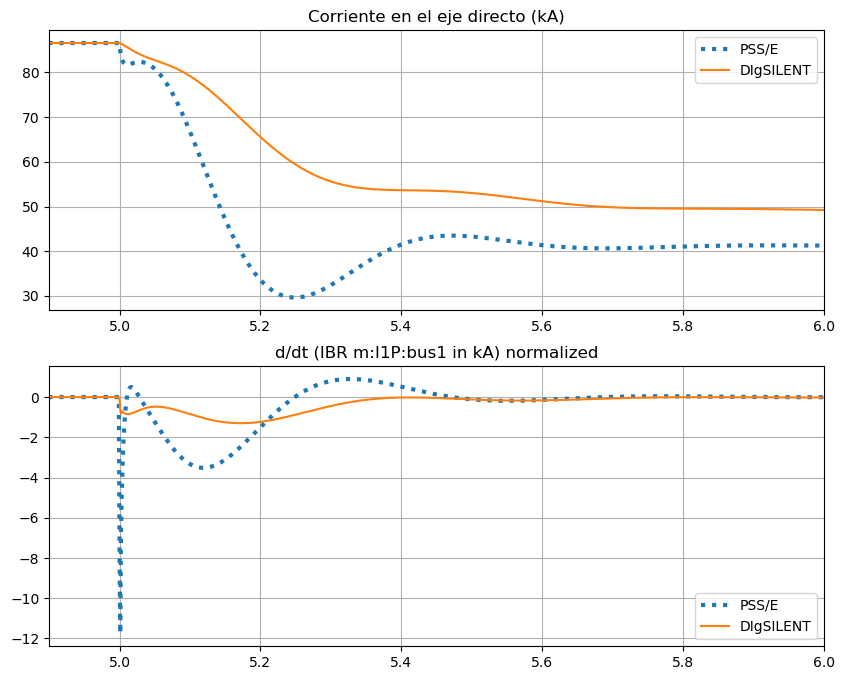

In [14]:
fig, axs = plt.subplots(2,1, figsize=(10,8))

minx = 4.9
maxx = 6

axs[0].plot(pss_04['Time(s)'], pss_04['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=3,)
axs[0].plot(dsl_04['Time in S'], dsl_04['IBR m:I1P:bus1 in kA'], label='DIgSILENT') #!!!! Calcular a parte
# axs[0].set_ylim(0.72, 0.77)
axs[0].set_xlim(minx, maxx)
axs[0].set_title('Corriente en el eje directo (kA)')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(pss_04_new['Time(s)'], pss_04_new[pss_04_title], linestyle=':', linewidth=3, label='PSS/E')
axs[1].plot(dsl_04_new['Time in S'], dsl_04_new[dsl_04_title], label='DIgSILENT')
axs[1].set_xlim(minx, maxx)
axs[1].legend()
axs[1].set_title(dsl_04_title)
axs[1].grid(True)

plt.show()

In [89]:
def Juan(dframe1, dframe2, df1_column, df2_column, decimals=3, time_column1=0, time_column2=0):
    df1_columns = dframe1.columns
    df2_columns = dframe2.columns
    
    if df1_column in df1_columns and df2_column in df2_columns:
        dslindex = dframe1.columns.get_loc(df1_column)
        pssindex = dframe2.columns.get_loc(df2_column)

        dframe1 = dframe1.iloc[:,[time_column1, dslindex]]
        dframe2 = dframe2.iloc[:,[time_column2, pssindex]]

        dframe1.iloc[:,0] = HUP_round(dframe1.iloc[:,0], decimals)
        dframe2.iloc[:,0] = HUP_round(dframe2.iloc[:,0], decimals)

        dframe1 = dframe1.drop_duplicates(df1_columns[time_column1], keep='first', ignore_index=True)
        dframe2 = dframe2.drop_duplicates(df2_columns[time_column2], keep='first', ignore_index=True)

        result = pd.merge(
            dframe1, dframe2,
            how='inner',
            left_on=df1_columns[time_column1],
            right_on=df2_columns[time_column2]
        )

        result.loc[:, 'sqr. error'] = (result[df1_column] - result[df2_column])**2

        transient = result.loc[(abs(result[df1_column])>0.02)|(abs(result[df2_column])>0.02), :]
        stdystate  = result.loc[(abs(result[df1_column])<0.02)&(abs(result[df2_column])<0.02), :]

        genError = np.sqrt(sum(result['sqr. error']/result.shape[0]))
        trnError = np.sqrt(sum(transient['sqr. error']/transient.shape[0]))
        sstError = np.sqrt(sum(stdystate['sqr. error']/stdystate.shape[0]))

        # return 
        return genError, trnError, sstError, result, transient, stdystate

In [90]:
jose, juan, armando, perez, vazquez, valgamez = Juan(dsl_04_new, pss_04_new, dsl_04_title, pss_04_title)
print(f'Error general: {jose:.6f} pu/s')
print(f'Error en los transitorios: {juan:.6f} pu/s')
print(f'Error en estado estable:   {armando:.6f} pu/s')

Error general: 0.220866 pu/s
Error en los transitorios: 1.029206 pu/s
Error en estado estable:   0.001642 pu/s


In [93]:
valgamez

,Time in S,d/dt (IBR m:I1P:bus1 in kA) normalized,Time(s),d/dt (IBR_ID (kA)) normalized,sqr. error
0,-0.002,0.0,-0.002,0.0,0.0
1,-0.001,0.0,-0.001,0.0,0.0
2,0.000,0.0,0.000,0.0,0.0
3,0.001,0.0,0.001,0.0,0.0
4,0.002,0.0,0.002,0.0,0.0
...,...,...,...,...,...
19995,19.996,0.0,19.996,0.0,0.0
19996,19.997,0.0,19.997,0.0,0.0
19997,19.998,0.0,19.998,0.0,0.0
19998,19.999,0.0,19.999,0.0,0.0


In [62]:
jose.shape[0] + rober.shape[0]

20000

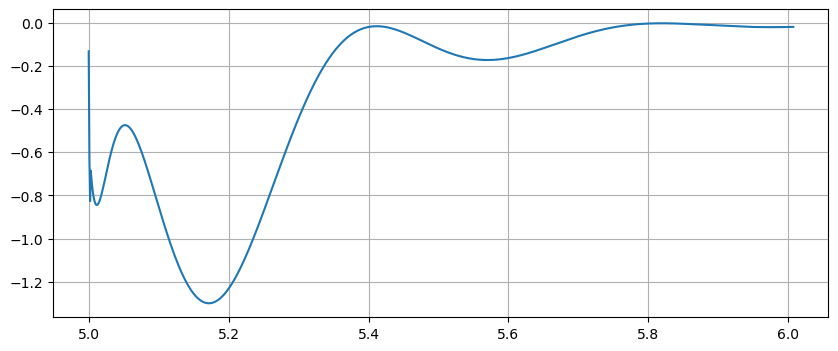

In [56]:
fig = plt.subplots(figsize=(10,4))
# plt.plot(jesus['Time(s)'], jesus[pss_04_title], label='PSS/E', linestyle=':', linewidth=3)
plt.plot(jesus['Time(s)'], jesus[dsl_04_title], label='DIgSILENT')

# plt.xlim(4.9,6)
plt.grid(True)
plt.show()